## Notebook Setup

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
from utils.set_random_seed import set_random_seed

set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

In [3]:
def get_train_sets(df):
    groundtruth_train = df.filter((pl.col("subfolder") == "debug") & (pl.col("split") == "train"))
    
    X_train = []
    y_train = []



    for exp in EXPERIMENTS:
        gt_exp = groundtruth_train.filter(pl.col("experiment") == exp)
        
        X_gt_exp = gt_exp.select("input").to_numpy()
        X_gt_exp = np.array([i[0] for i in X_gt_exp])
        y_gt_exp = gt_exp.select("evaluation").to_numpy()
        

        # Reshape into 500 arrays with 2000 samples each
        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        total_samples = len(X_gt_exp)
        num_arrays = 500
        samples_per_array = total_samples // num_arrays
        
        # Reshape groundtruth data: (500*2000,) -> (500, 2000)
        X_gt_reshaped = []
        y_gt_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_gt_reshaped.append(X_gt_exp[i::num_arrays])
            y_gt_reshaped.append(y_gt_exp[i::num_arrays])
        

        X_train.append(X_gt_reshaped)
        y_train.append(y_gt_reshaped)

    return X_train, y_train

def get_test_sets(df):
    groundtruth_test = df.filter((pl.col("subfolder") == "debug") & (pl.col("split") == "test"))

    X_test = []
    y_test = []


    for exp in EXPERIMENTS:
        gt_exp = groundtruth_test.filter(pl.col("experiment") == exp)

        X_gt_exp = gt_exp.select("input").to_numpy()
        X_gt_exp = np.array([i[0] for i in X_gt_exp])
        y_gt_exp = gt_exp.select("evaluation").to_numpy()
        
        # Reshape into 500 arrays with 200 samples each
        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        total_samples = len(X_gt_exp)
        num_arrays = 500
        samples_per_array = total_samples // num_arrays
        
        # Reshape groundtruth data: (500*200,) -> (500, 200)
        X_gt_reshaped = []
        y_gt_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_gt_reshaped.append(X_gt_exp[i::num_arrays])
            y_gt_reshaped.append(y_gt_exp[i::num_arrays])
        
        # Reshape judge data: (500*200,) -> (500, 200)
    
        X_test.append(X_gt_reshaped)
        y_test.append(y_gt_reshaped)


    return X_test, y_test

In [4]:
import os

df = []

for subfolder in ["debug"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 100]",i32,str,str,str
0,0,"[0, 1, … 0]",0,"""debug""","""experiment_1""","""train"""
0,1,"[0, 1, … 0]",1,"""debug""","""experiment_1""","""train"""
0,2,"[0, 1, … 0]",0,"""debug""","""experiment_1""","""train"""
0,3,"[0, 1, … 0]",0,"""debug""","""experiment_1""","""train"""
0,4,"[0, 1, … 0]",1,"""debug""","""experiment_1""","""train"""


## Logistic Regression

In [4]:
## Load best param
import json


best_params = {
    "debug": []
}

for f in sorted(os.listdir("best_params")):
    _params = []
    results = json.load(open(f"best_params/{f}", "r"))["results"]
    for p in results:
        try:
            _params.append(p["best_params"])
        except KeyError:
            _params.append(None)
    
    if "debug" in f:
        best_params["debug"].append(_params)


In [ ]:
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

X_train, y_train = get_train_sets(df)
debug_models = []

with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _j_arr, _g_arr = [], []
        for j in range(500):
            # Groundtruth model
            X_gt = X_train[i][j]
            y_gt = y_train[i][j].ravel()
            
            if best_params["debug"][i][j] is None:
                _g_arr.append(None)
            else:
                model_gt = LogisticRegression(**best_params["debug"][i][j], max_iter=1000, random_state=42)
                model_gt.fit(X_gt, y_gt)
                _g_arr.append(model_gt)
            

            
            pbar.update(1)
        
        debug_models.append(_g_arr)
        
del X_train, y_train
gc.collect()

Training models:   9%|████████████▏                                                                                                                               | 217/2500 [00:23<03:49,  9.93it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:  29%|████████████████████████████████████████▋                                                                                                   | 726/2500 [01:23<01:52, 15.71it/s]

In [ ]:
### saving weights as tensores



from numpy import float64


# for exp in range(len(EXPERIMENTS)):
#     torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in debug_models[exp]]), f"weights/debug/{EXPERIMENTS[exp]}/lr_weights.pt")
#     torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in debug_models[exp]]), f"weights/debug/{EXPERIMENTS[exp]}/lr_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    debug_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_debug/"
    os.makedirs(debug_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in debug_models[exp]]), f"{debug_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in debug_models[exp]]), f"{debug_path}/0_499_bias.pt")


/tmp/ipykernel_2428996/3530059746.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in debug_models[exp]]), f"weights/debug/{EXPERIMENTS[exp]}/lr_weights.pt")


RuntimeError: Parent directory weights/debug/experiment_1 does not exist.

In [22]:
from sklearn.metrics import roc_auc_score
X_test, y_test = get_test_sets(df)


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        debug_lr = debug_models[i][j]
        if debug_lr is not None:

            _x = X_test[i][j]
            _y = y_test[i][j].ravel()
            score = roc_auc_score(_y, debug_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("debug")
            _eval_df["auc"].append(score)



del X_test, y_test
gc.collect()

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarnin

237

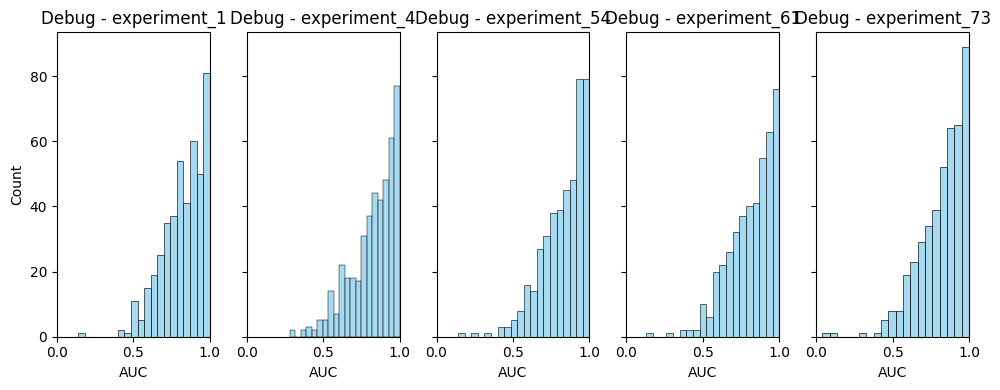

In [28]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)
fig, axes = plt.subplots(1, 5, figsize=(10, 4), sharex=True, sharey=True)
color_map = {"debug": "#87CEEB"}  # Pastel blue

for row, exp in enumerate(EXPERIMENTS):
    subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
    sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row])
    axes[row].set_title(f"{t.capitalize()} - {exp}")
    axes[row].set_xlim(0, 1)
    axes[row].set_ylabel("Count")
    axes[row].set_xlabel("AUC")

plt.tight_layout()
plt.show()

## Text Generation Analysis

In [6]:
from utils.metrics.calculate_metric import calculate_agg_metric


wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "debug" in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('_')[1].split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/debug_logistic_regression.feather")
else:
    generations_results = pl.read_ipc("generation_results/debug_logistic_regression.feather")        

Processing lr_debug.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_debug.json for experiment experiment_4...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_debug.json for experiment experiment_54...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_debug.json for experiment experiment_61...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_debug.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


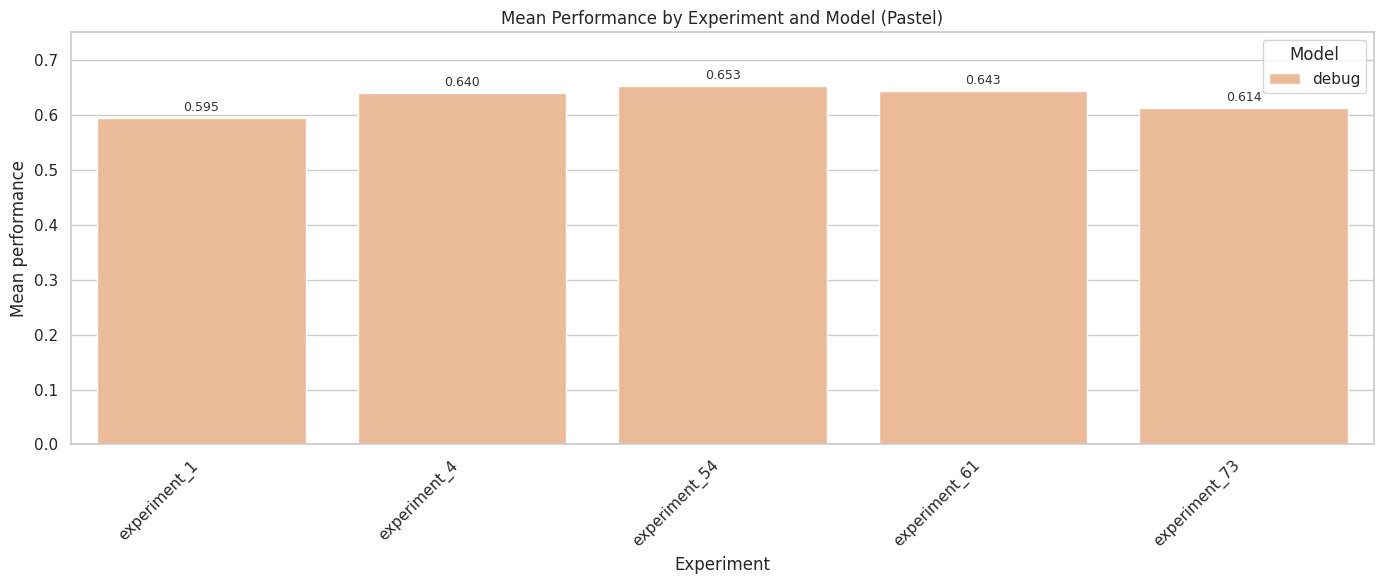

In [7]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["debug"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "debug": "#F8B88B",        # pastel yellow
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()